# IPIP-300 Personality Analysis

This project analyses a large open-access dataset (N=145,388) from the International Personality Item Pool (IPIP), scored using the Five-Factor-E library (Johnson, 2014). The dataset provides pre-computed scores for the Big Five personality domains and their 30 facets, alongside basic demographic variables.

The analysis examines personality structure and individual differences across age and sex, with the goal of replicating established findings from the personality development literature and exploring facet-level patterns often overlooked in domain-level analyses.

**Dataset:** openpsychometrics.org · N=145,388 · collected 2001–2011  
**Final sample after cleaning:** N=107,335 (26.1% removed)  
**Scoring:** Five-Factor-E library — domain and facet percentile scores (1–100)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
%matplotlib inline
plt.rcParams['figure.dpi'] = 80
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
from scipy.stats import ttest_ind
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Functions
# Reusable style f.

COLORS = ['#2D4A6B', '#C1775A', '#6B9E78', '#8B7BA8', '#D4A853', '#5B8FA8']
BG     = '#F7F4EF'
PANEL  = '#FFFFFF'
GRID   = '#E8E4DE'
FACET_COLORS = ['#2D4A6B', '#C1775A', '#6B9E78', '#8B7BA8', '#D4A853', '#5B8FA8']

def style_axes(ax, title='', xlabel='', ylabel='', fontsize_title=11, fontsize_labels=9):
    """Apply consistent style to any axis."""
    ax.set_facecolor(PANEL)
    ax.set_title(title, fontsize=fontsize_title, fontfamily='serif')
    ax.set_xlabel(xlabel, fontsize=fontsize_labels)
    ax.set_ylabel(ylabel, fontsize=fontsize_labels)
    ax.tick_params(labelsize=fontsize_labels)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.yaxis.grid(True, color=GRID, zorder=0)
    ax.set_axisbelow(True)


def plot_hist(ax, data, color, title='', xlabel='Score', ylabel='Count',
              bins=40, mean_line=True):
    """Plot a histogram with optional mean line."""
    ax.hist(data, bins=bins, color=color, edgecolor='none', alpha=0.85)
    ax.relim()
    ax.autoscale_view()
    if mean_line:
        m = data.mean()
        ax.axvline(m, color='#C1775A', linewidth=1.5, linestyle='--')
        ax.text(m + 1, ax.get_ylim()[1] * 0.9,
                f'Mean: {m:.1f}', color='#C1775A', fontsize=9)
    style_axes(ax, title=title, xlabel=xlabel, ylabel=ylabel)


def style_fig(fig, title='', y=0.98):
    """Apply consistent style to figure."""
    fig.patch.set_facecolor(BG)
    if title:
        fig.suptitle(title, fontsize=15, fontfamily='serif', y=y)

# Cohen's D f.

def cohens_d(group1, group2):
    """Compute Cohen's d effect size between two groups.
    Positive d = group1 > group2."""
    n1, n2     = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    # pooled standard deviation weighted by group size
    pooled_sd  = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_sd

# Correlation matrices f.

def plot_corr(ax, data, title='', annot=True, cmap='coolwarm', vmin=-1, vmax=1):
    """Plot a full correlation matrix heatmap."""
    corr = data.corr()
    sns.heatmap(corr, ax=ax, annot=annot, fmt='.2f',
                cmap=cmap, vmin=vmin, vmax=vmax,
                linewidths=0.5, linecolor=GRID,
                annot_kws={'size': 7},
                cbar_kws={'shrink': 0.8})
    style_axes(ax, title=title)
    ax.tick_params(labelsize=8, rotation=45)

## I. Data Loading & Column Definitions

Raw data is loaded without modification. Column groups are defined here and reused throughout the notebook to avoid hardcoding variable names.

In [3]:
df_raw = pd.read_csv('IPIP300-SCORES.csv')

meta_cols = ['case', 'sex', 'age', 'country', 'year', 'month', 'day', 'hour', 'min', 'sec']

item_cols = [c for c in df_raw.columns if c.startswith('i') and c[1:].isdigit()]

domain_cols = ['openness', 'conscientiousness', 'extraversion', 'agreeableness', 'neuroticism']

facet_cols = [c for c in df_raw.columns if c.startswith('facet_')]

score_cols = domain_cols + facet_cols

facets_by_domain = {
    'openness':          ['facet_imagination', 'facet_artistic_interests', 'facet_emotionality',
                          'facet_adventurousness', 'facet_intellect', 'facet_liberalism'],
    'conscientiousness': ['facet_self_efficacy', 'facet_orderliness', 'facet_dutifulness',
                          'facet_achievement_striving', 'facet_self_discipline', 'facet_cautiousness'],
    'extraversion':      ['facet_friendliness', 'facet_gregariousness', 'facet_assertiveness',
                          'facet_activity_level', 'facet_excitement_seeking', 'facet_cheerfulness'],
    'agreeableness':     ['facet_trust', 'facet_morality', 'facet_altruism',
                          'facet_cooperation', 'facet_modesty', 'facet_sympathy'],
    'neuroticism':       ['facet_anxiety', 'facet_anger', 'facet_depression',
                          'facet_self_consciousness', 'facet_immoderation', 'facet_vulnerability']
}

print(f"Shape: {df_raw.shape}")
print(f"Items: {len(item_cols)}")
print(f"Domains: {len(domain_cols)}")
print(f"Facets: {len(facet_cols)}")
print(f"Total scores: {len(score_cols)}")

Shape: (145388, 345)
Items: 300
Domains: 5
Facets: 30
Total scores: 35


## II. Data Cleaning

Four exclusion criteria were applied: participants under 18 (IPIP-300 norms are derived from adult reference populations), participants over 70 (n=62 in the 71–90 bin, insufficient for stable estimates), countries with fewer than 500 responses, and invalid sex codes. Year and month variables were recoded from Perl localtime encoding (years since 1900, months 0–11).

In [4]:
# Under 18: IPIP-300 scoring norms are derived from adult reference populations
# Over 90: very small cell sizes at the extremes, risk of age-related confounds
df_clean = df_raw.copy()

# --- Fix year and month encoding
df_clean['year'] = df_clean['year'] + 1900
df_clean['month'] = df_clean['month'] + 1

# --- Recode sex
df_clean['sex'] = df_clean['sex'].map({1: 'Male', 2: 'Female'})

# --- Filter age (keep 18-80)
age_before = len(df_clean)
df_clean = df_clean[(df_clean['age'] >= 18) & (df_clean['age'] <= 70)].copy()
age_after = len(df_clean)
print(f"Age filter: {age_before - age_after:,} rows removed ({(age_before - age_after)/age_before*100:.1f}%)")

# --- Filter countries (keep n >= 500)
country_counts = df_clean['country'].value_counts()
valid_countries = country_counts[country_counts >= 500].index
country_before = len(df_clean)
df_clean = df_clean[df_clean['country'].isin(valid_countries)].copy()
country_after = len(df_clean)
print(f"Country filter: {country_before - country_after:,} rows removed ({(country_before - country_after)/country_before*100:.1f}%)")

# --- Drop rows with missing sex
sex_before = len(df_clean)
df_clean = df_clean[df_clean['sex'].isin(['Male', 'Female'])].copy()
print(f"Sex filter: {sex_before - len(df_clean):,} rows removed")

print(f"\nFinal shape: {df_clean.shape}")
print(f"Countries kept: {df_clean['country'].nunique()}")
print(f"Sex distribution:\n{df_clean['sex'].value_counts()}")

Age filter: 28,185 rows removed (19.4%)
Country filter: 9,868 rows removed (8.4%)
Sex filter: 0 rows removed

Final shape: (107335, 345)
Countries kept: 14
Sex distribution:
sex
Female    62872
Male      44463
Name: count, dtype: int64


## III. Derived Dataframes

Two working dataframes are constructed from the cleaned data and reused throughout:
- **df_scores** — demographics + 35 computed scores (no raw items)
- **df_country** — mean Big Five scores per country, sorted by sample size

df_scores: (107335, 39)
df_country: (14, 5)


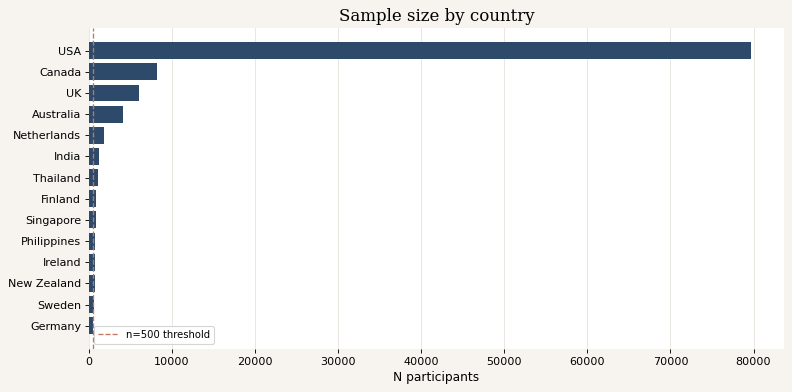

In [5]:
# df_scores: demographics + computed scores only
df_scores = df_clean[['case', 'sex', 'age', 'country'] + score_cols].copy()

# df_country: mean Big Five per country, sorted by sample size
df_country = df_clean.groupby('country')[domain_cols].mean().round(2)
country_order = df_clean['country'].value_counts().index
df_country = df_country.reindex(country_order)

print(f"df_scores: {df_scores.shape}")
print(f"df_country: {df_country.shape}")

# sample size per country — bar chart
country_counts = df_clean['country'].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#F7F4EF')
ax.set_facecolor('#FFFFFF')
bars = ax.barh(country_counts.index[::-1], country_counts.values[::-1],
               color='#2D4A6B', edgecolor='none')
ax.set_xlabel('N participants', fontsize=11)
ax.set_title('Sample size by country', fontsize=15, fontfamily='serif')
ax.axvline(500, color='#C1775A', linestyle='--', linewidth=1.2, label='n=500 threshold')
ax.legend(fontsize=9)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.xaxis.grid(True, color='#E8E4DE', zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

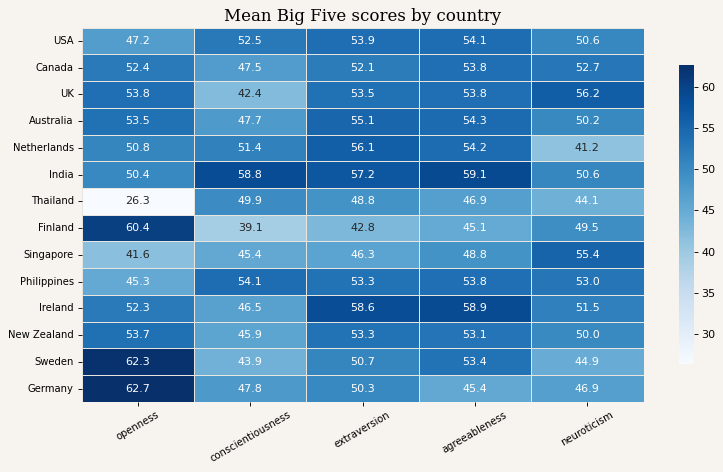

In [6]:
# heatmap of mean Big Five scores per country
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#F7F4EF')
ax.set_facecolor('#FFFFFF')
sns.heatmap(df_country,
            annot=True,
            fmt='.1f',
            cmap='Blues',
            linewidths=0.5,
            linecolor='#E8E4DE',
            ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Mean Big Five scores by country', fontsize=15, fontfamily='serif')
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=9, rotation=30)
ax.tick_params(axis='y', labelsize=9, rotation=0)
plt.tight_layout()
plt.show()

## IV. Descriptive Statistics & Demographics

Sample overview: age distribution, sex breakdown, and Big Five score distributions.

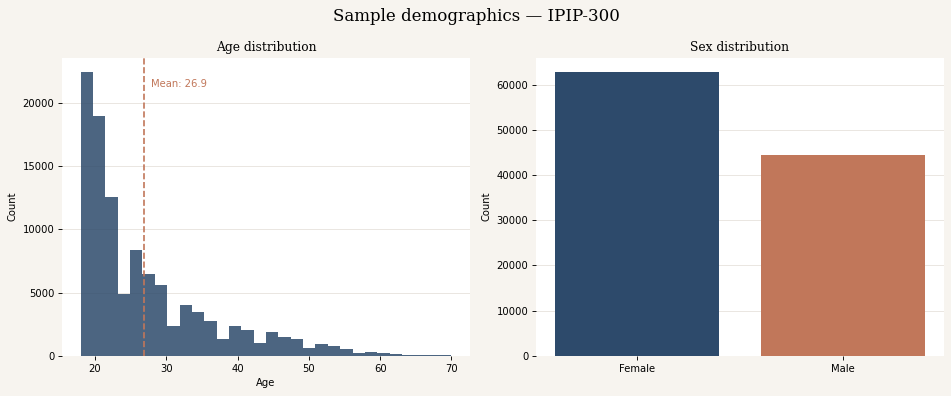

In [7]:
fig1, axes = plt.subplots(1, 2, figsize=(12, 5))
style_fig(fig1, title='Sample demographics — IPIP-300')

plot_hist(axes[0], df_clean['age'], color=COLORS[0],
          title='Age distribution', xlabel='Age', ylabel='Count', bins=30)

sex_counts = df_clean['sex'].value_counts()
axes[1].bar(sex_counts.index, sex_counts.values,
            color=[COLORS[0], COLORS[1]], edgecolor='none')
style_axes(axes[1], title='Sex distribution', ylabel='Count')

plt.tight_layout()
plt.show()

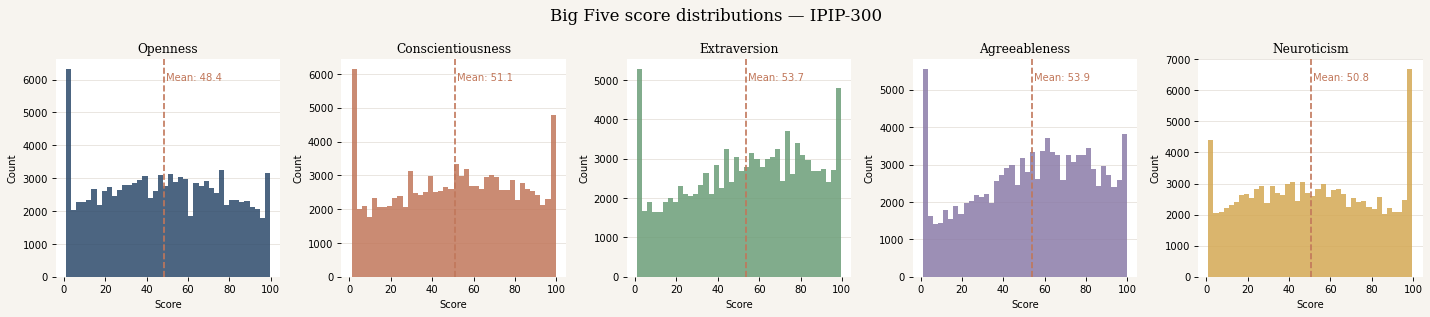

In [8]:
fig2, axes = plt.subplots(1, 5, figsize=(18, 4))
style_fig(fig2, title='Big Five score distributions — IPIP-300')

for ax, domain, color in zip(axes, domain_cols, COLORS):
    plot_hist(ax, df_clean[domain], color=color,
              title=domain.capitalize(), xlabel='Score', ylabel='Count')

plt.tight_layout()
plt.show()

In [9]:
# bin age into decades for trajectory analysis
df_clean['age_group'] = pd.cut(df_clean['age'],
                                bins=[18, 30, 40, 50, 60, 70],
                                labels=['18-30', '31-40', '41-50', '51-60', '61-70'])

# mean + std per age group per domain
age_trajectories = df_clean.groupby('age_group', observed=True)[domain_cols].mean()
age_trajectories_std = df_clean.groupby('age_group', observed=True)[domain_cols].std()

print(age_trajectories.round(1))
print(df_clean['age_group'].value_counts().sort_index())

           openness  conscientiousness  extraversion  agreeableness  \
age_group                                                             
18-30          49.1               49.1          54.9           52.3   
31-40          48.4               53.3          51.4           54.0   
41-50          47.7               58.5          49.4           60.5   
51-60          48.2               62.5          47.9           64.5   
61-70          47.5               64.2          47.9           64.2   

           neuroticism  
age_group               
18-30             52.0  
31-40             50.8  
41-50             45.8  
51-60             41.4  
61-70             38.2  
age_group
18-30    67761
31-40    16229
41-50     8316
51-60     2982
61-70      407
Name: count, dtype: int64


## V. Age × Personality Trajectories

Age was binned into five decade groups (18–30 through 61–70). Groups are unequal in size (18–30: n=67,761; 61–70: n=407) which means that trajectories in older groups should be interpreted with caution. Domain-level trends are examined first, followed by facet-level analysis within each domain.

Expected findings (Roberts et al., 2006; Soto et al., 2011): conscientiousness increases, neuroticism decreases, agreeableness increases with age.

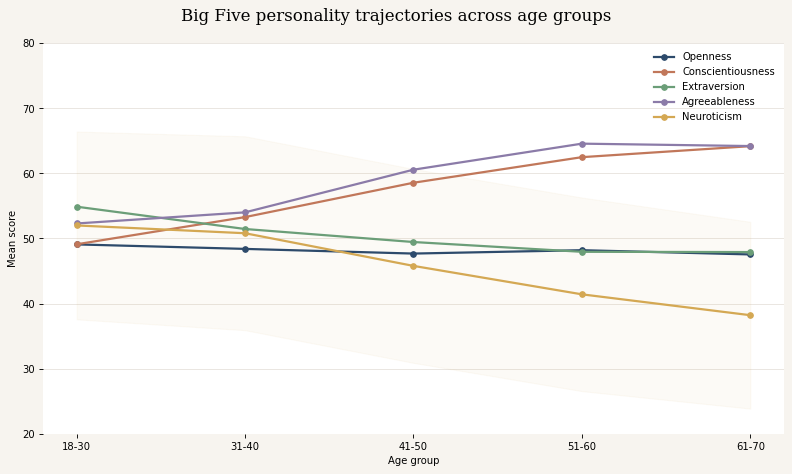

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
style_fig(fig, title='Big Five personality trajectories across age groups')

for domain, color in zip(domain_cols, COLORS):
    means = age_trajectories[domain]
    stds  = age_trajectories_std[domain]
    
    ax.plot(means.index, means.values, color=color, linewidth=2, marker='o',
            markersize=5, label=domain.capitalize())
ax.fill_between(means.index,
                means.values - stds.values * 0.5,
                means.values + stds.values * 0.5,
                color=color, alpha=0.05)

style_axes(ax, xlabel='Age group', ylabel='Mean score', fontsize_labels=9)
ax.legend(fontsize=9, frameon=False)
ax.set_ylim(20, 80)

plt.tight_layout()
plt.show()

## VI. Sex Differences

Independent samples t-tests for all 5 domains and 30 facets. Given N~107k, virtually all p-values will reach significance, that's why Cohen's d is the primary metric. Thresholds: d=0.2 small, d=0.5 medium, d=0.8 large.

In [11]:
males   = df_clean[df_clean['sex'] == 'Male']
females = df_clean[df_clean['sex'] == 'Female']

results = []
for domain in domain_cols:
    t, p = ttest_ind(males[domain], females[domain])
    d    = cohens_d(males[domain], females[domain])
    results.append({'domain':    domain,
                    't':         round(t, 3),
                    'p':         round(p, 4),
                    'd':         round(d, 3),
                    'male_mean': round(males[domain].mean(), 1),
                    'female_mean': round(females[domain].mean(), 1)})

df_sex = pd.DataFrame(results)
print(df_sex)

              domain       t       p      d  male_mean  female_mean
0           openness  23.881  0.0000  0.148       50.9         46.7
1  conscientiousness  -4.841  0.0000 -0.030       50.6         51.5
2       extraversion   0.147  0.8834  0.001       53.7         53.7
3      agreeableness  -2.362  0.0182 -0.015       53.7         54.1
4        neuroticism -14.765  0.0000 -0.091       49.3         51.9


In [12]:
# note: effect sizes are smaller than typically reported in the literature
# (d ~0.3-0.5 for neuroticism). likely reflects online sampling bias
# and percentile normalization compressing group differences.
# openness male advantage unusual — warrants caution in interpretation.

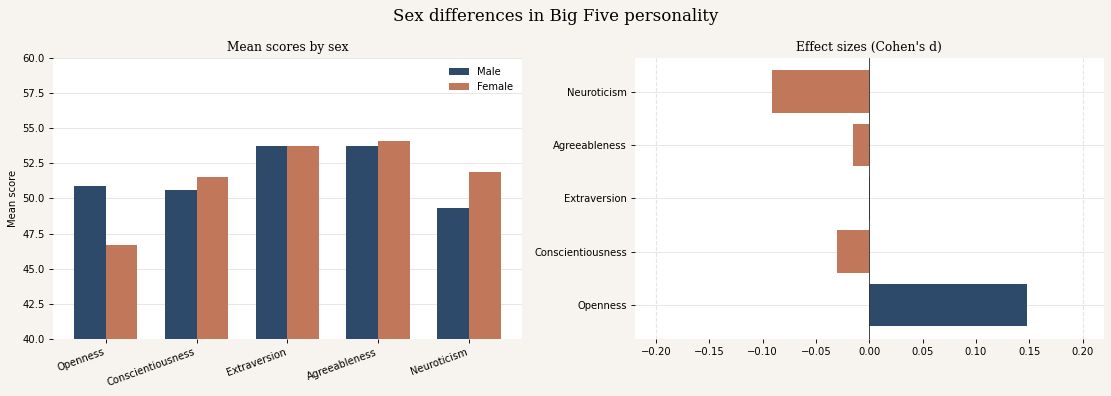

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
style_fig(fig, title='Sex differences in Big Five personality')

# --- Panel 1: Mean scores by sex
x = np.arange(len(domain_cols))
width = 0.35

axes[0].bar(x - width/2, df_sex['male_mean'],   width=width,
            color=COLORS[0], edgecolor='none', label='Male')
axes[0].bar(x + width/2, df_sex['female_mean'], width=width,
            color=COLORS[1], edgecolor='none', label='Female')

axes[0].set_xticks(x)
axes[0].set_xticklabels([d.capitalize() for d in domain_cols], rotation=20, ha='right')
axes[0].legend(fontsize=9, frameon=False)
axes[0].set_ylim(40, 60)
style_axes(axes[0], title='Mean scores by sex', ylabel='Mean score')

# --- Panel 2: Cohen's d effect sizes
colors_d = [COLORS[0] if d >= 0 else COLORS[1] for d in df_sex['d']]
axes[1].barh(df_sex['domain'].str.capitalize(), df_sex['d'],
             color=colors_d, edgecolor='none')
axes[1].axvline(0, color='#333333', linewidth=0.8)
axes[1].axvline( 0.2, color=GRID, linewidth=1, linestyle='--')
axes[1].axvline(-0.2, color=GRID, linewidth=1, linestyle='--')
axes[1].set_xlabel("Cohen's d  (positive = males higher)", fontsize=9)
style_axes(axes[1], title="Effect sizes (Cohen's d)")

plt.tight_layout()
plt.show()

## VII. Correlation Matrices

Pearson correlations at two levels: domain-level (5×5) and facet-level (30×30). The facet matrix is ordered by domain to make within-domain and between-domain correlation blocks visible.

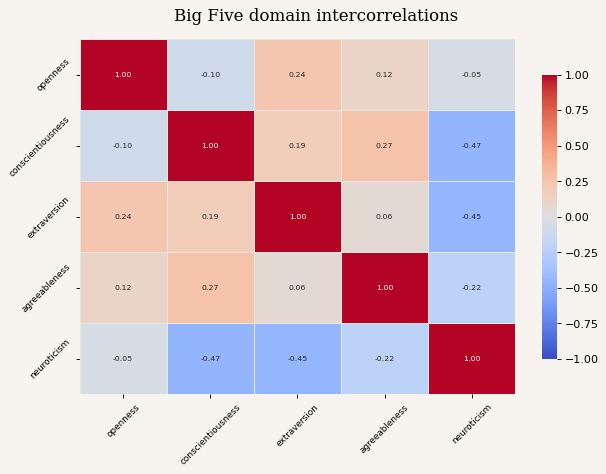

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
style_fig(fig, title='Big Five domain intercorrelations')

plot_corr(ax, df_scores[domain_cols], title='')

plt.tight_layout()
plt.show()

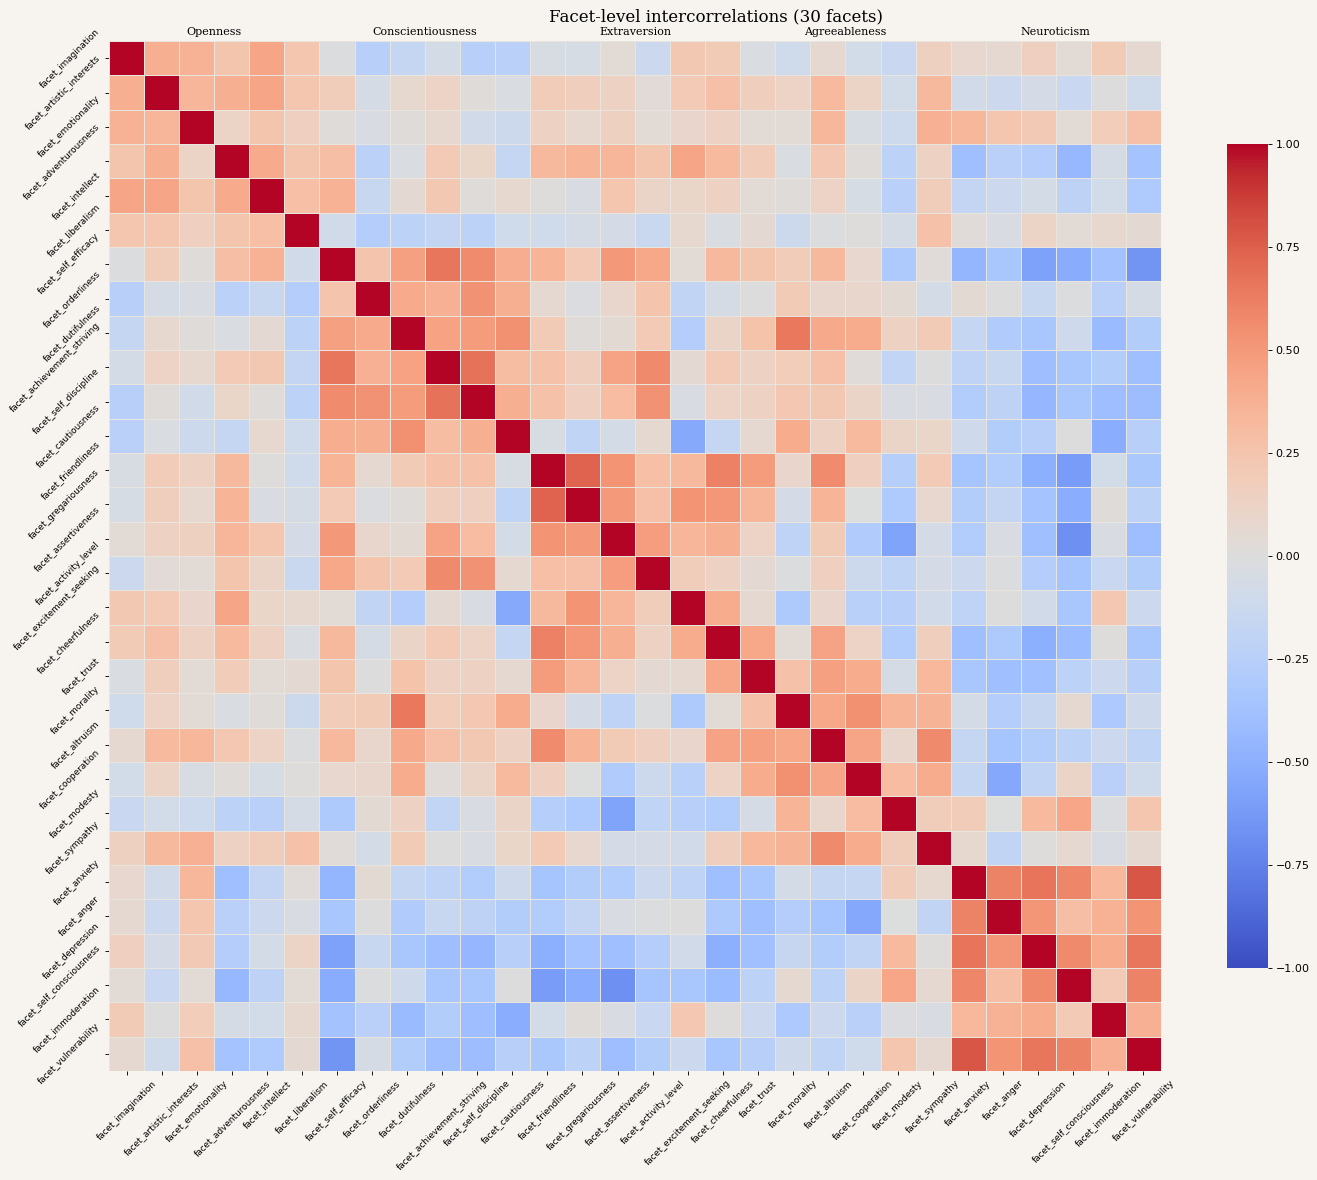

In [15]:
# order facets by domain for readability
ordered_facets = []
for domain in domain_cols:
    ordered_facets += facets_by_domain[domain]

fig, ax = plt.subplots(figsize=(18, 15))
style_fig(fig, title='Facet-level intercorrelations (30 facets)')

plot_corr(ax, df_scores[ordered_facets], title='', annot=False)

# add domain labels on x axis
domain_positions = [3, 9, 15, 21, 27]  # midpoint of each domain's 6 facets
domain_names     = [d.capitalize() for d in domain_cols]
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(domain_positions)
ax2.set_xticklabels(domain_names, fontsize=10, fontfamily='serif')
ax2.tick_params(length=0)
for spine in ax2.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

## VIII. Facet-Level Age Trajectories

Same binning as section 5, applied at the facet level. Each domain is plotted separately to preserve readability across 6 facets per panel.

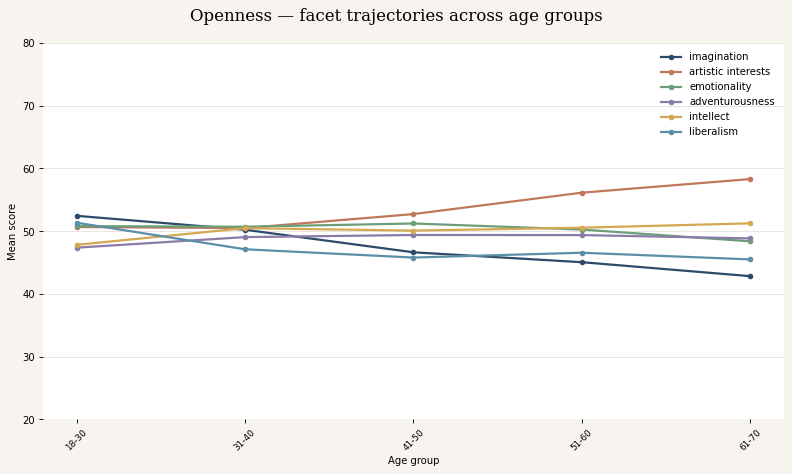

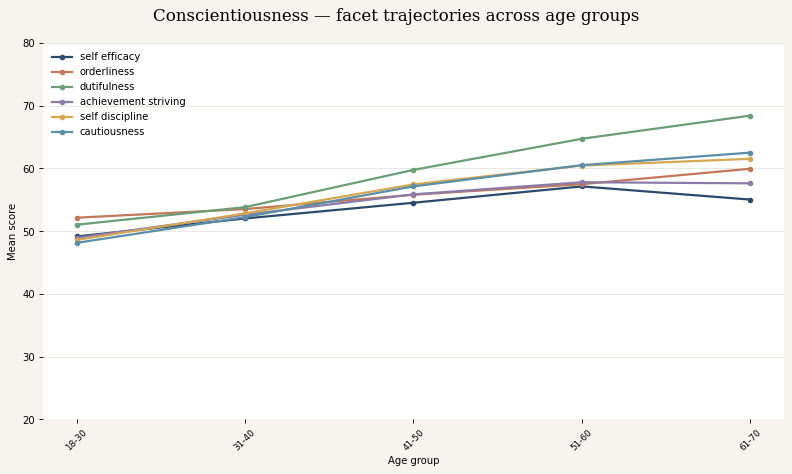

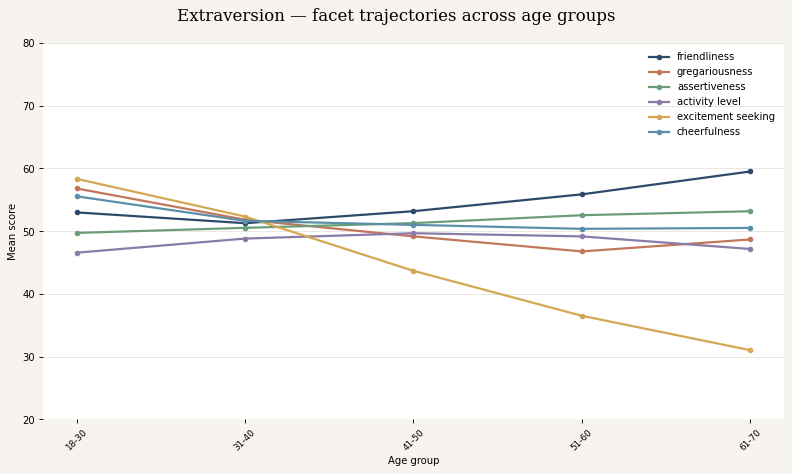

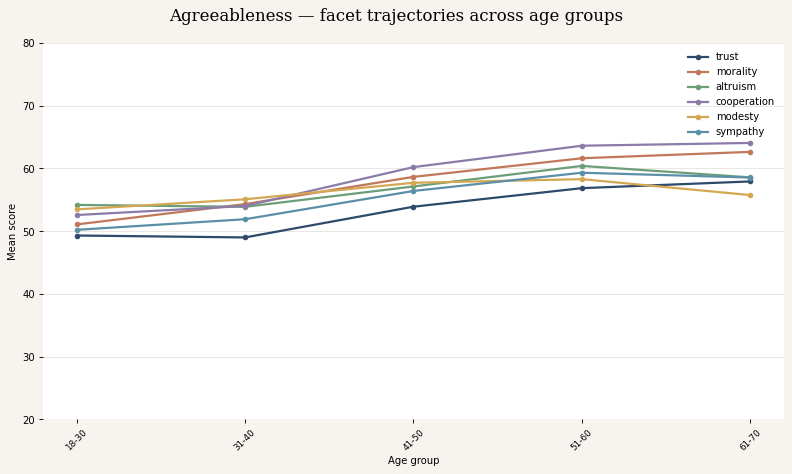

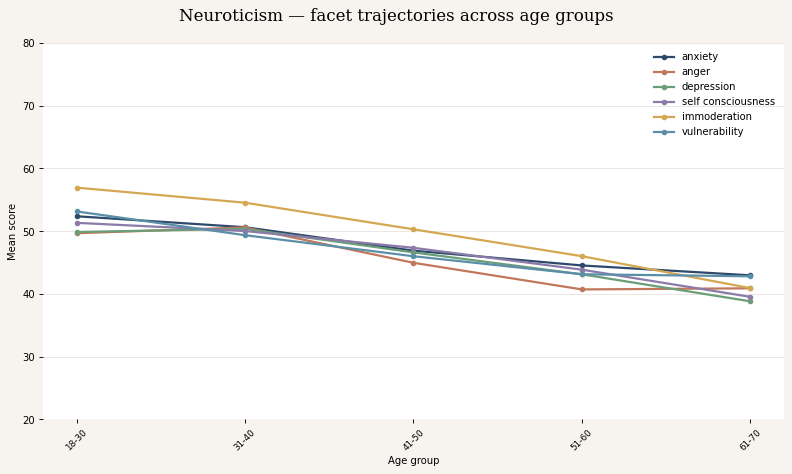

In [16]:
facet_trajectories = df_clean.groupby('age_group', observed=True)[facet_cols].mean()

for domain in domain_cols:
    fig, ax = plt.subplots(figsize=(10, 6))
    style_fig(fig, title=f'{domain.capitalize()} — facet trajectories across age groups')
    ax.set_facecolor(PANEL)
    
    for facet, color in zip(facets_by_domain[domain], FACET_COLORS):
        label = facet.replace('facet_', '').replace('_', ' ')
        ax.plot(facet_trajectories.index, facet_trajectories[facet],
                color=color, linewidth=2, marker='o', markersize=4, label=label)
    
    style_axes(ax, xlabel='Age group', ylabel='Mean score')
    ax.set_ylim(20, 80)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.legend(fontsize=9, frameon=False)
    plt.tight_layout()
    plt.show()

## IX. Facet-Level Sex Differences

Cohen's d computed for all 30 facets. Positive d = males higher, negative d = females higher. Results plotted per domain for direct comparison with the age trajectory patterns above.

In [17]:
results_facet_sex = []
for domain, facets in facets_by_domain.items():
    for facet in facets:
        d = cohens_d(males[facet], females[facet])
        t, p = ttest_ind(males[facet], females[facet])
        results_facet_sex.append({
            'domain': domain,
            'facet':  facet.replace('facet_', '').replace('_', ' '),
            'd':      round(d, 3),
            'p':      round(p, 4)
        })

df_facet_sex = pd.DataFrame(results_facet_sex)
print(df_facet_sex.to_string())

               domain                 facet      d       p
0            openness           imagination  0.091  0.0000
1            openness    artistic interests  0.073  0.0000
2            openness          emotionality -0.014  0.0281
3            openness       adventurousness  0.094  0.0000
4            openness             intellect  0.153  0.0000
5            openness            liberalism  0.139  0.0000
6   conscientiousness         self efficacy  0.087  0.0000
7   conscientiousness           orderliness -0.074  0.0000
8   conscientiousness           dutifulness  0.008  0.2162
9   conscientiousness  achievement striving  0.007  0.2482
10  conscientiousness       self discipline -0.049  0.0000
11  conscientiousness          cautiousness -0.035  0.0000
12       extraversion          friendliness  0.000  0.9909
13       extraversion        gregariousness  0.004  0.5668
14       extraversion         assertiveness -0.023  0.0002
15       extraversion        activity level -0.049  0.00

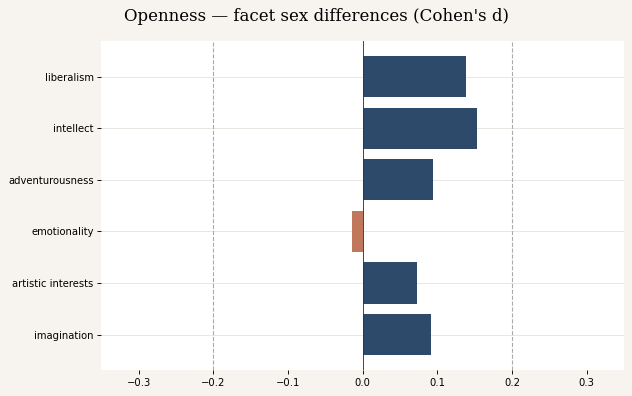

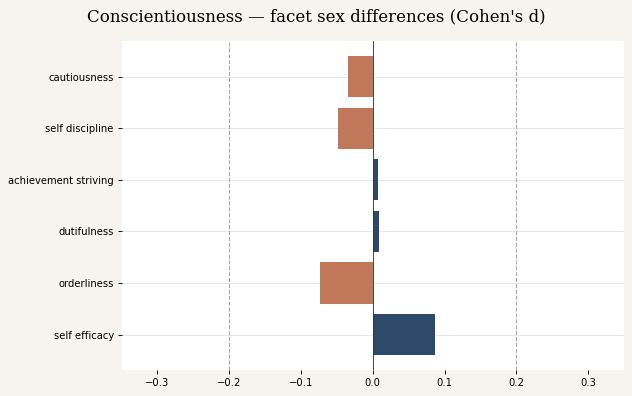

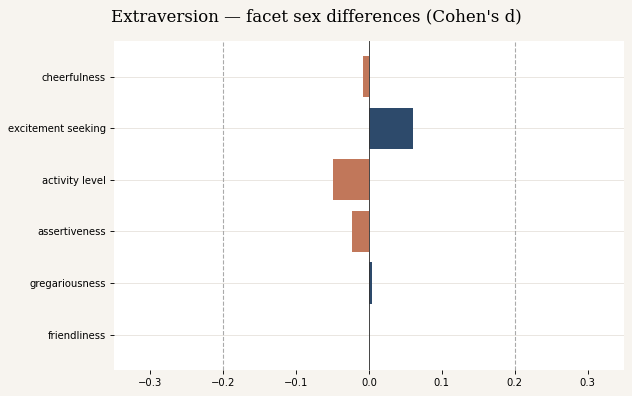

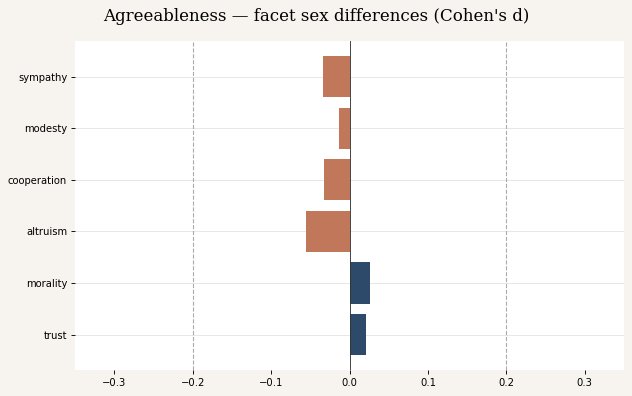

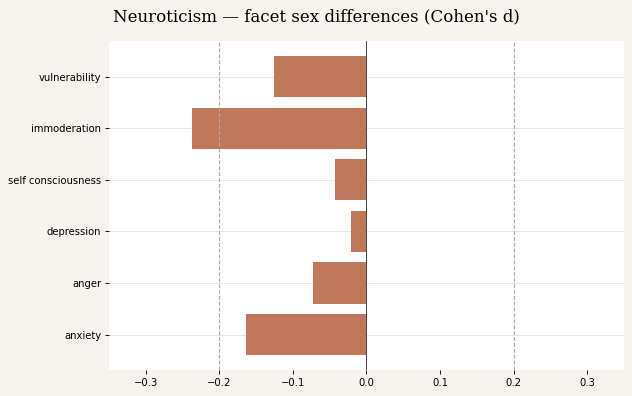

In [18]:
males   = df_clean[df_clean['sex'] == 'Male']
females = df_clean[df_clean['sex'] == 'Female']

results_facet_sex = []
for domain, facets in facets_by_domain.items():
    for facet in facets:
        d = cohens_d(males[facet], females[facet])
        t, p = ttest_ind(males[facet], females[facet])
        results_facet_sex.append({
            'domain': domain,
            'facet':  facet.replace('facet_', '').replace('_', ' '),
            'd':      round(d, 3),
            'p':      round(p, 4)
        })

df_facet_sex = pd.DataFrame(results_facet_sex)

for domain in domain_cols:
    data = df_facet_sex[df_facet_sex['domain'] == domain].copy()
    bar_colors = [COLORS[0] if d >= 0 else COLORS[1] for d in data['d']]

    fig, ax = plt.subplots(figsize=(8, 5))
    style_fig(fig, title=f"{domain.capitalize()} — facet sex differences (Cohen's d)")
    ax.barh(data['facet'], data['d'], color=bar_colors, edgecolor='none')
    ax.axvline(0, color='#333333', linewidth=0.8)
    ax.axvline( 0.2, color='#AAAAAA', linewidth=1, linestyle='--')
    ax.axvline(-0.2, color='#AAAAAA', linewidth=1, linestyle='--')
    ax.set_xlim(-0.35, 0.35)
    ax.set_xlabel("Cohen's d  (positive = males higher, negative = females higher)", fontsize=9)
    style_axes(ax, title='')
    ax.tick_params(axis='y', labelsize=9)
    plt.tight_layout()
    plt.show()
    plt.close()

## X. Personality Profiles & K-Means Clustering

K-means clustering on standardised domain scores to identify latent personality profiles. Optimal k determined via the elbow method.

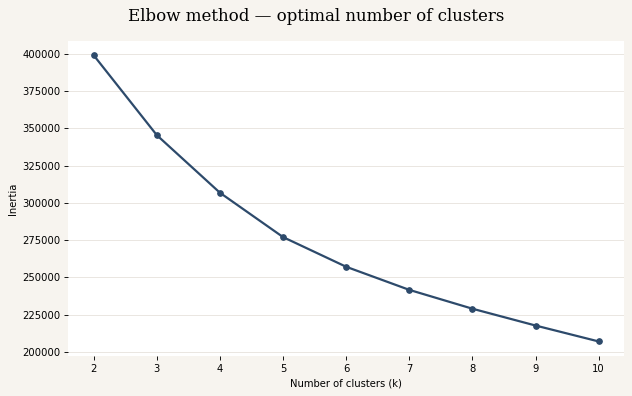

In [19]:
scaler = StandardScaler()
X = scaler.fit_transform(df_scores[domain_cols])

# elbow method
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
style_fig(fig, title='Elbow method — optimal number of clusters')
ax.plot(k_range, inertias, color=COLORS[0], linewidth=2, marker='o', markersize=5)
style_axes(ax, xlabel='Number of clusters (k)', ylabel='Inertia')
plt.tight_layout()
plt.show()
plt.close()

In [20]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df_scores['cluster'] = km.fit_predict(X)

# cluster sizes
print(df_scores['cluster'].value_counts().sort_index())

cluster
0    27692
1    27814
2    27746
3    24083
Name: count, dtype: int64


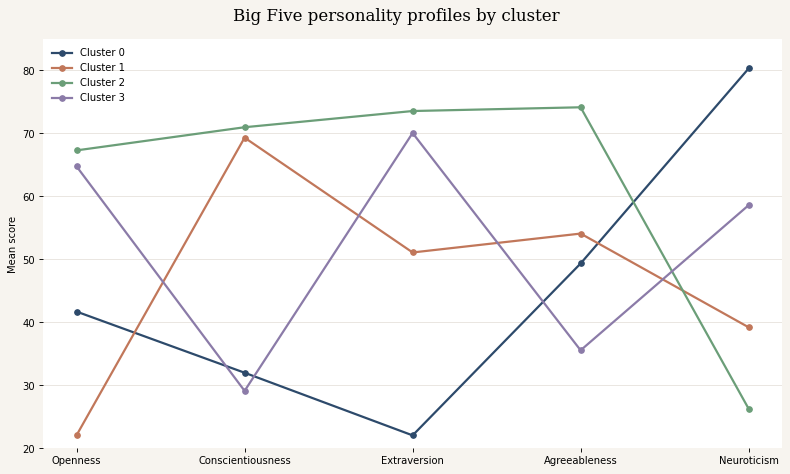

In [21]:
# mean Big Five per cluster
cluster_profiles = df_scores.groupby('cluster')[domain_cols].mean()

fig, ax = plt.subplots(figsize=(10, 6))
style_fig(fig, title='Big Five personality profiles by cluster')

for cluster in range(4):
    ax.plot(domain_cols, cluster_profiles.loc[cluster],
            color=COLORS[cluster], linewidth=2, marker='o',
            markersize=5, label=f'Cluster {cluster}')

ax.set_xticks(range(len(domain_cols)))
ax.set_xticklabels([d.capitalize() for d in domain_cols], fontsize=9)
ax.set_ylim(20, 85)
ax.legend(fontsize=9, frameon=False)
style_axes(ax, ylabel='Mean score')
plt.tight_layout()
plt.show()
plt.close()

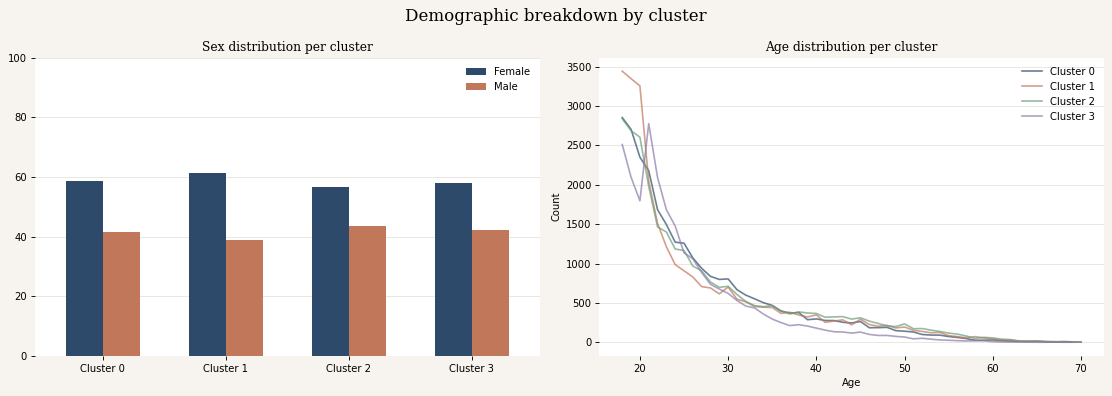

In [22]:
# merge cluster labels back with clean data
df_cluster = df_clean.copy()
df_cluster['cluster'] = df_scores['cluster'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
style_fig(fig, title='Demographic breakdown by cluster')

# --- Panel 1: Sex distribution per cluster
sex_cluster = pd.crosstab(df_cluster['cluster'], df_cluster['sex'], normalize='index') * 100

sex_cluster.plot(kind='bar', ax=axes[0], color=[COLORS[0], COLORS[1]],
                 edgecolor='none', width=0.6)
axes[0].set_xticklabels([f'Cluster {i}' for i in range(4)], rotation=0, fontsize=9)
axes[0].set_ylabel('% of cluster', fontsize=9)
axes[0].legend(fontsize=9, frameon=False)
axes[0].set_ylim(0, 100)
style_axes(axes[0], title='Sex distribution per cluster')

# --- Panel 2: Age distribution per cluster
for i, color in enumerate(COLORS[:4]):
    data = df_cluster[df_cluster['cluster'] == i]['age']
    axes[1].plot(sorted(data.unique()),
                 [data[data == a].count() for a in sorted(data.unique())],
                 color=color, linewidth=1.5, alpha=0.7, label=f'Cluster {i}')

style_axes(axes[1], title='Age distribution per cluster',
           xlabel='Age', ylabel='Count')
axes[1].legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.show()
plt.close()